<a href="https://colab.research.google.com/github/oladimeji-kazeem/healthscan/blob/master/hypertensionipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from xgboost import plot_importance
import shap

# **1. Research Objective**

Develop and evaluate machine learning models that can predict the likelihood of hypertension based ondemographic, lifestyle, and clinical factors.

In [46]:
df_hypertension = pd.read_csv('/content/drive/MyDrive/seyi/datasetss/hypertention.csv')

# **2. Research Key Questions**

*   Which factors contribute most to hypertension risk.
*   Which ML model performs best for prediction?
*   Can lifestyle variables alone predict hypertension effectively?
*   How early can we detect risk before clinical diagnosis?


In [47]:
df_hypertension.head()

,Unnamed: 0,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,0,69,8.0,9,Normal,6.4,25.8,NaN,Yes,Low,Non-Smoker,Yes
1,1,32,11.7,10,Normal,5.4,23.4,NaN,No,Low,Non-Smoker,No
2,2,78,9.5,3,Normal,7.1,18.7,NaN,No,Moderate,Non-Smoker,No
3,3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No


# **3. Dataset Understanding**

Your dataset contains the following variables:
- Age
- Salt Intake
- Stress Score
- BP History
- Sleep Duration
- BMI
- Medication
- Family History
- Exercise Level
- Smoking Status
- Has Hypertension

In [48]:
# How many rows
df_hypertension.shape[0]

1985

In [49]:
# How many columns
df_hypertension.shape[1]

12

In [50]:
# How many columns
df_hypertension.head()

,Unnamed: 0,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,0,69,8.0,9,Normal,6.4,25.8,NaN,Yes,Low,Non-Smoker,Yes
1,1,32,11.7,10,Normal,5.4,23.4,NaN,No,Low,Non-Smoker,No
2,2,78,9.5,3,Normal,7.1,18.7,NaN,No,Moderate,Non-Smoker,No
3,3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No


In [51]:
# identify the prediction target
# To check the balance state of the target variable.
df_hypertension["Has_Hypertension"].value_counts()

,count
Has_Hypertension,
Yes,1032
No,953


In [52]:
#check columns
df_hypertension.dtypes

,0
Unnamed: 0,int64
Age,int64
Salt_Intake,float64
Stress_Score,int64
BP_History,object
Sleep_Duration,float64
BMI,float64
Medication,object
Family_History,object
Exercise_Level,object


In [53]:
# categorical features
df_hypertension.select_dtypes(include="object").columns

Index(['BP_History', 'Medication', 'Family_History', 'Exercise_Level',
       'Smoking_Status', 'Has_Hypertension'],
      dtype='object')

In [54]:
# numerical features
df_hypertension.describe()

,Unnamed: 0,Age,Salt_Intake,Stress_Score,Sleep_Duration,BMI
count,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000
mean,992.000000,50.341058,8.531688,4.979345,6.452242,26.015315
std,573.164462,19.442042,1.994907,3.142303,1.542207,4.512857
min,0.000000,18.000000,2.500000,0.000000,1.500000,11.900000
25%,496.000000,34.000000,7.200000,2.000000,5.400000,23.000000
50%,992.000000,50.000000,8.500000,5.000000,6.500000,25.900000
75%,1488.000000,67.000000,9.900000,8.000000,7.500000,29.100000
max,1984.000000,84.000000,16.400000,10.000000,11.400000,41.900000


In [55]:
#missing values
df_hypertension.isnull().sum()

,0
Unnamed: 0,0
Age,0
Salt_Intake,0
Stress_Score,0
BP_History,0
Sleep_Duration,0
BMI,0
Medication,799
Family_History,0
Exercise_Level,0


# **4. Methodology**

**Step 1: Data Preprocessing**

- Handle missing values
- Encode categorical variables (e.g. smoking, gender)
- Normalize/standardize numerical features.
- Remove outliers (optional but valiable)

In [56]:
# fill the missing values with mode
df_hypertension["Medication"].fillna(df_hypertension["Medication"].mode()[0], inplace=True)

/tmp/ipykernel_51558/533768700.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_hypertension["Medication"].fillna(df_hypertension["Medication"].mode()[0], inplace=True)


In [57]:
df_hypertension.isnull().sum()

,0
Unnamed: 0,0
Age,0
Salt_Intake,0
Stress_Score,0
BP_History,0
Sleep_Duration,0
BMI,0
Medication,0
Family_History,0
Exercise_Level,0


In [58]:
#drop duplicatess
# fill the missing values with mode
df_hypertension.duplicated().sum()

np.int64(0)

<Axes: >

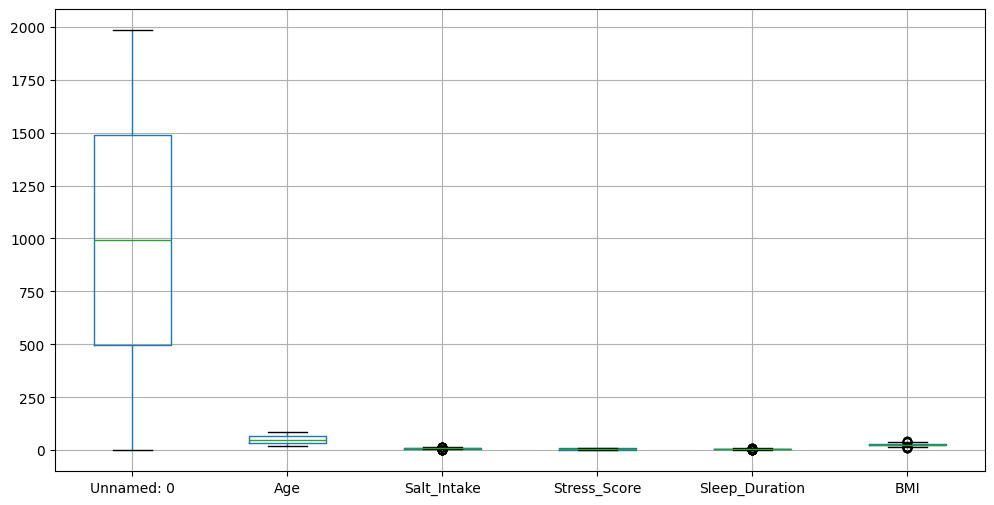

In [59]:
# outliers
df_hypertension.boxplot(figsize=(12,6))

array([[<Axes: title={'center': 'Unnamed: 0'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Salt_Intake'}>,
        <Axes: title={'center': 'Stress_Score'}>],
       [<Axes: title={'center': 'Sleep_Duration'}>,
        <Axes: title={'center': 'BMI'}>]], dtype=object)

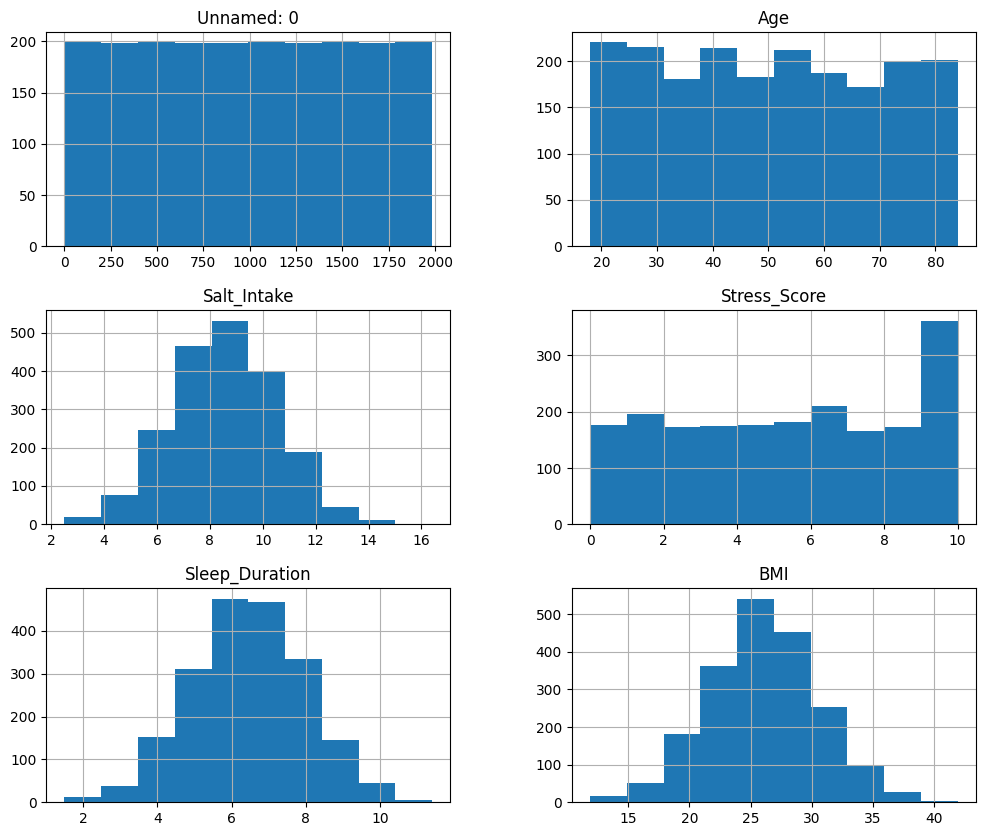

In [60]:
df_hypertension.hist(figsize=(12,10))

In [61]:
#copy the dataset
dfh = df_hypertension.copy()

In [62]:
dfh.head()

,Unnamed: 0,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,0,69,8.0,9,Normal,6.4,25.8,Beta Blocker,Yes,Low,Non-Smoker,Yes
1,1,32,11.7,10,Normal,5.4,23.4,Beta Blocker,No,Low,Non-Smoker,No
2,2,78,9.5,3,Normal,7.1,18.7,Beta Blocker,No,Moderate,Non-Smoker,No
3,3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No


In [63]:
dfh["BP_History"].value_counts()

,count
BP_History,
Normal,796
Prehypertension,620
Hypertension,569


<Axes: xlabel='count', ylabel='BP_History'>

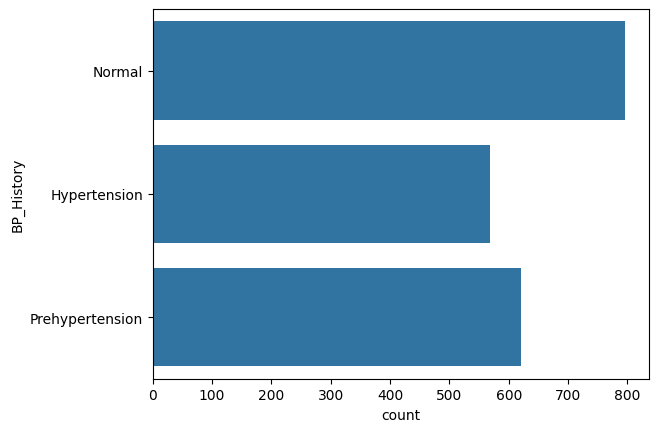

In [65]:
sns.countplot(dfh["BP_History"])

In [64]:
dfh["Medication"].value_counts()

,count
Medication,
Beta Blocker,1211
ACE Inhibitor,323
Diuretic,245
Other,206


<Axes: xlabel='count', ylabel='Medication'>

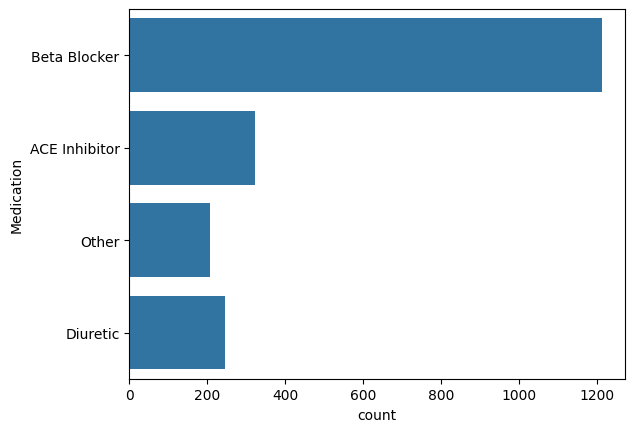

In [66]:
sns.countplot(dfh["Medication"])

In [40]:
dfh["Exercise_Level"].value_counts()

,count
Exercise_Level,
Low,936
Moderate,658
High,391


<Axes: xlabel='count', ylabel='Exercise_Level'>

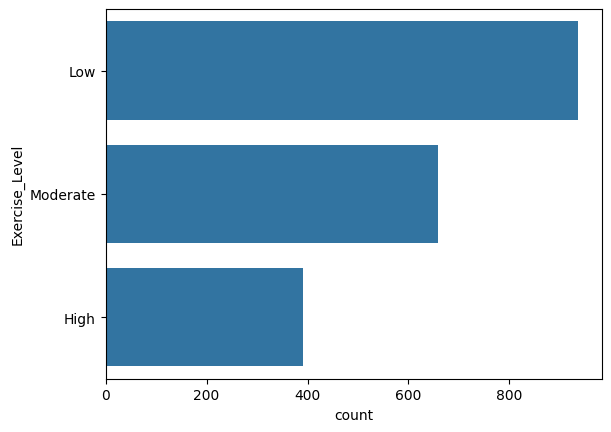

In [67]:
sns.countplot(dfh["Exercise_Level"])

In [41]:
dfh['Smoking_Status'].value_counts()

,count
Smoking_Status,
Non-Smoker,1417
Smoker,568


<Axes: xlabel='count', ylabel='Smoking_Status'>

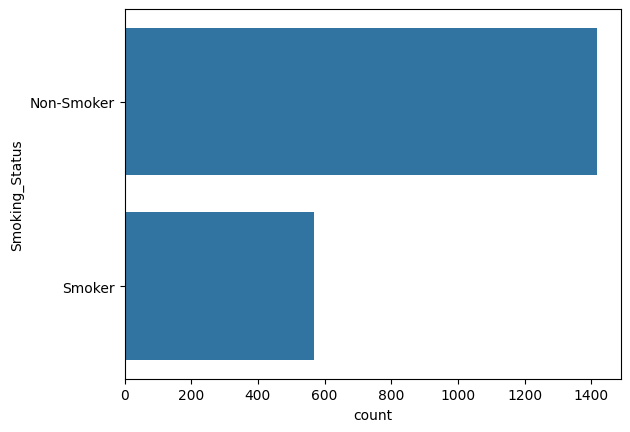

In [68]:
sns.countplot(dfh["Smoking_Status"])

In [70]:
#encoding
cat_cols = ['BP_History', 'Medication', 'Family_History', 'Exercise_Level', 'Smoking_Status', 'Has_Hypertension']
num_cols = ['Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration', 'BMI']

In [71]:
le = LabelEncoder()

for x in cat_cols:
  dfh[x] = le.fit_transform(dfh[x])

In [72]:
dfh.head()

,Unnamed: 0,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,0,69,8.0,9,1,6.4,25.8,1,1,1,0,1
1,1,32,11.7,10,1,5.4,23.4,1,0,1,0,0
2,2,78,9.5,3,1,7.1,18.7,1,0,2,0,0
3,3,38,10.0,10,0,4.2,22.1,0,0,1,0,1
4,4,41,9.8,1,2,5.8,16.2,3,0,2,0,0


**Step 2: Exploratory Data Analysis (EDA)**

- Correlation heatmap
- Distribution of hypertention vs non-hypertension
- Feature relationship (e.g. BMI vs BP)

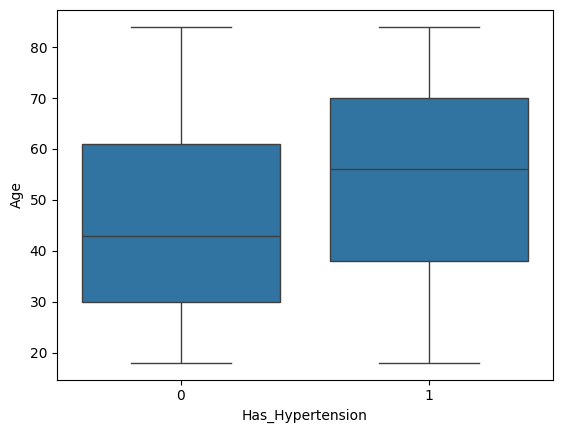

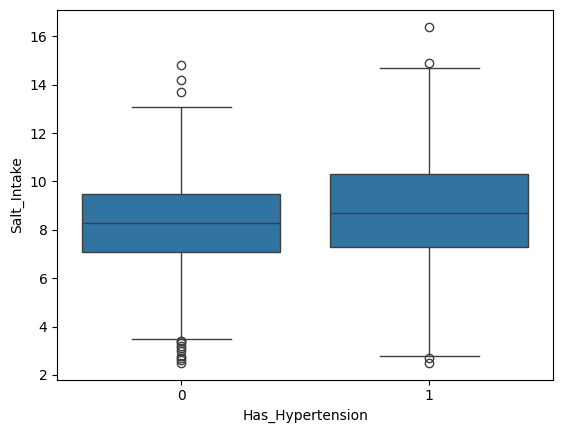

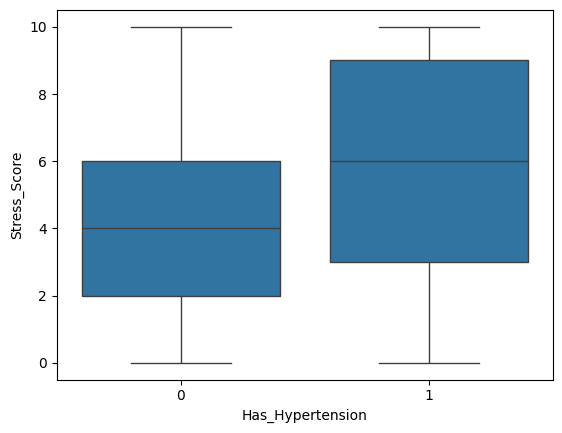

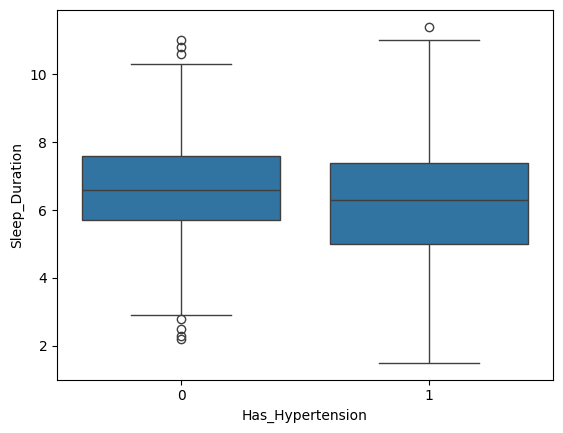

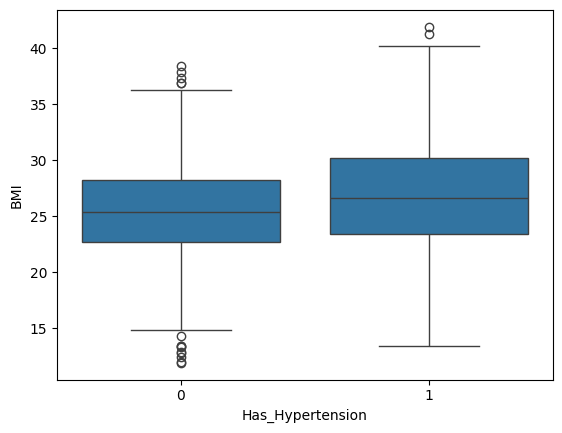

In [73]:
for y in num_cols:
  sns.boxplot(x="Has_Hypertension", y=y, data=dfh)
  plt.show()

In [74]:
df_corr = dfh.corr()

In [75]:
df_corr

,Unnamed: 0,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
Unnamed: 0,1.000000,-0.033221,-0.022128,-0.012526,0.041120,0.025581,-0.016344,-0.051880,-0.028319,-0.004331,-0.019159,-0.080050
Age,-0.033221,1.000000,0.011205,-0.032184,0.022068,-0.011839,-0.023498,0.013873,-0.000619,0.015054,0.003457,0.210677
Salt_Intake,-0.022128,0.011205,1.000000,0.008129,-0.011794,0.020394,0.039530,0.010105,-0.049213,-0.006669,-0.029285,0.114415
Stress_Score,-0.012526,-0.032184,0.008129,1.000000,0.027169,0.021191,0.011450,-0.021523,-0.008549,-0.033330,0.029000,0.186910
BP_History,0.041120,0.022068,-0.011794,0.027169,1.000000,-0.021359,-0.009539,-0.020310,-0.006913,-0.006254,-0.009501,-0.438679
Sleep_Duration,0.025581,-0.011839,0.020394,0.021191,-0.021359,1.000000,0.025476,0.023122,-0.012063,-0.012417,0.039781,-0.119561
BMI,-0.016344,-0.023498,0.039530,0.011450,-0.009539,0.025476,1.000000,-0.004916,0.018093,-0.006125,0.004546,0.145093
Medication,-0.051880,0.013873,0.010105,-0.021523,-0.020310,0.023122,-0.004916,1.000000,0.016289,0.050781,-0.013007,0.020102
Family_History,-0.028319,-0.000619,-0.049213,-0.008549,-0.006913,-0.012063,0.018093,0.016289,1.000000,0.004949,-0.010821,0.282144
Exercise_Level,-0.004331,0.015054,-0.006669,-0.033330,-0.006254,-0.012417,-0.006125,0.050781,0.004949,1.000000,0.019658,-0.006794


<Axes: >

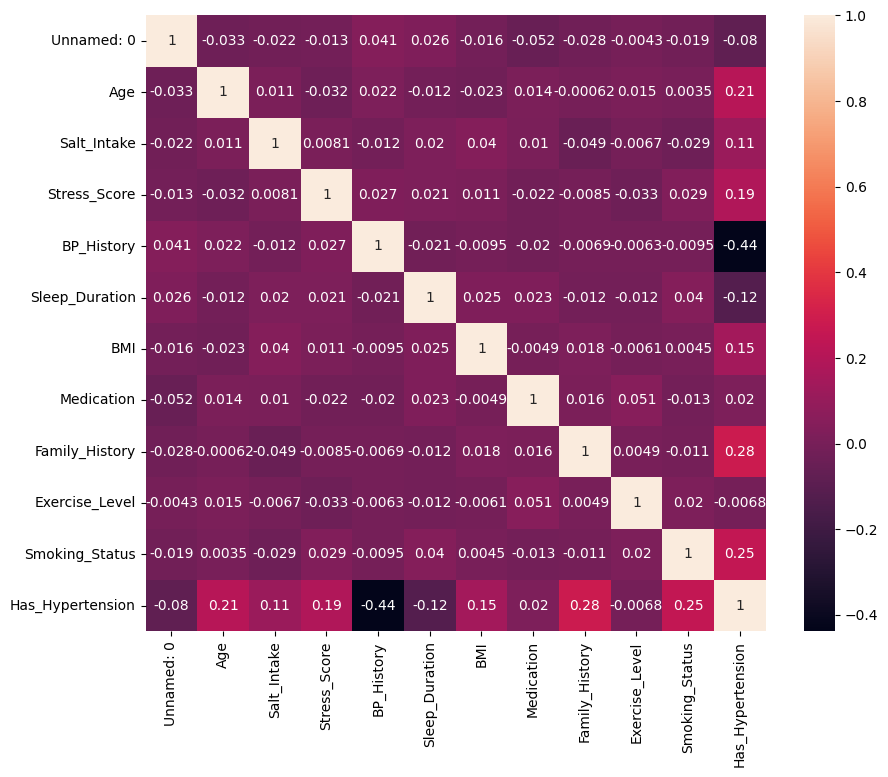

In [77]:
#heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df_corr, annot=True)

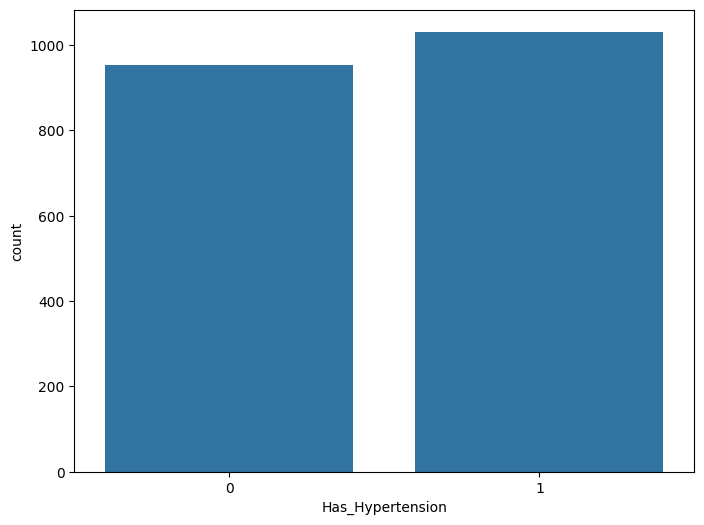

In [79]:
#Distribution of hypertention vs non-hypertension
plt.figure(figsize=(8,6))
sns.countplot(data=dfh, x="Has_Hypertension")
plt.show()

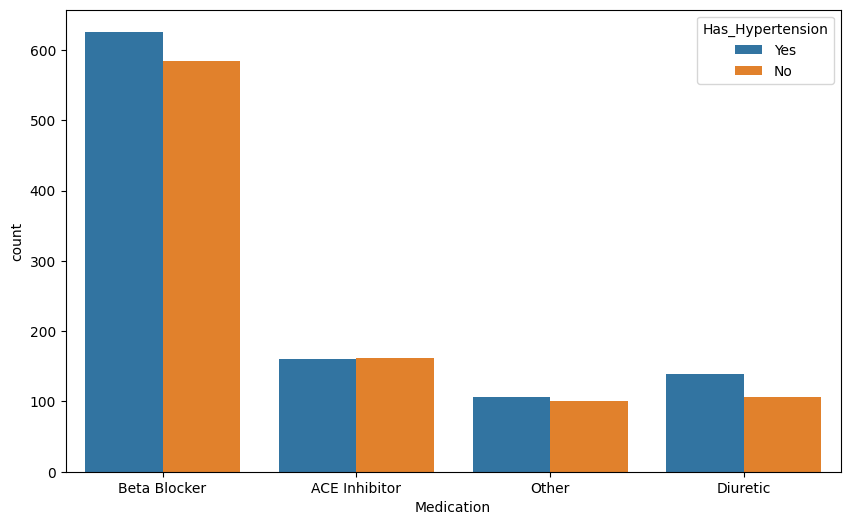

In [81]:
#Bivariate Analysis
plt.figure(figsize=(10,6))
sns.countplot(data=df_hypertension, x="Medication", hue="Has_Hypertension")
plt.show()

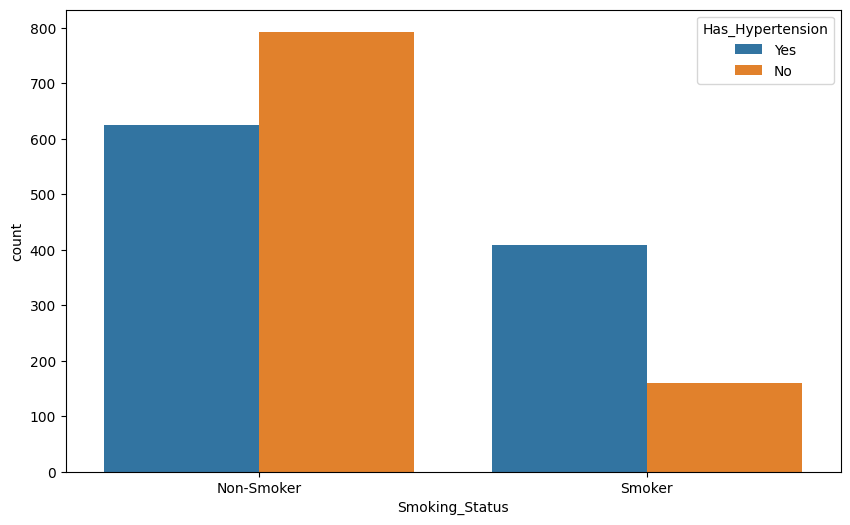

In [82]:
#Bivariate Analysis
plt.figure(figsize=(10,6))
sns.countplot(data=df_hypertension, x="Smoking_Status", hue="Has_Hypertension")
plt.show()

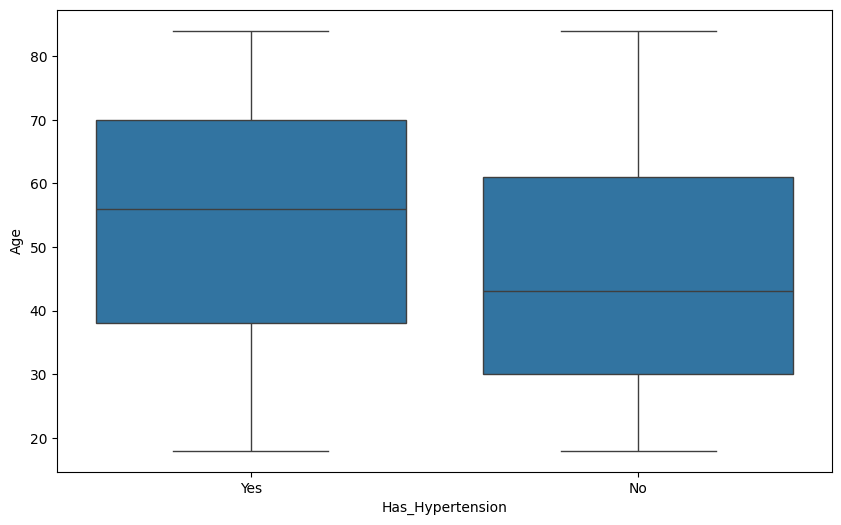

In [84]:
#Bivariate Analysis
plt.figure(figsize=(10,6))
sns.boxplot(data=df_hypertension, y="Age", x="Has_Hypertension")
plt.show()

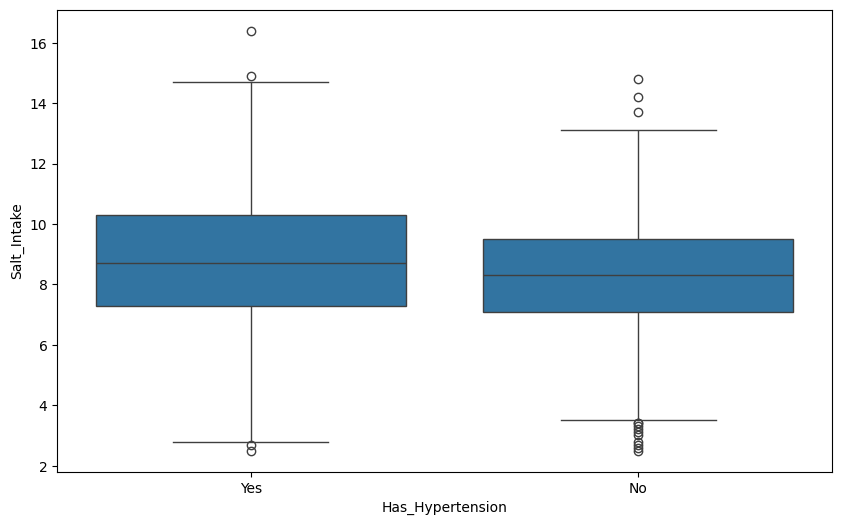

In [85]:
#Bivariate Analysis
plt.figure(figsize=(10,6))
sns.boxplot(data=df_hypertension, y="Salt_Intake", x="Has_Hypertension")
plt.show()

**Step 3: Model Selection**  
Train and compare multiple models:
- Logistics Regression
- Decision Tree
- Random Forest
- Gradient Boosting (XGBoost/LightGBM)
- Support Vector Machine (optional)

In [90]:
# split the features
X = dfh.drop("Has_Hypertension", axis=1)
y = dfh["Has_Hypertension"]

In [92]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [95]:
#scaling the data
scaler = StandardScaler()
X_train_scales = scaler.fit_transform(X_train)
X_test_scales = scaler.transform(X_test)

In [100]:
#trainin

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric = 'logloss'),
    "LightGBM": LGBMClassifier(probability = True)
}

results = {}

for name, model in models.items():
  model.fit(X_train_scales, y_train)

  y_pred = model.predict(X_test_scales)

  accuracy = accuracy_score(y_test, y_pred)

  results[name] = accuracy
  print(f"{name} Accuracy: {accuracy:.4f}")


Logistic Regression Accuracy: 0.8111
Decision Tree Accuracy: 0.9673
Random Forest Accuracy: 0.9622
XGBoost Accuracy: 0.9924
[LightGBM] [Warning] Unknown parameter: probability
[LightGBM] [Warning] Unknown parameter: probability
[LightGBM] [Info] Number of positive: 827, number of negative: 761
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000509 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 715
[LightGBM] [Info] Number of data points in the train set: 1588, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.520781 -> initscore=0.083171
[LightGBM] [Info] Start training from score 0.083171
[LightGBM] [Warning] Unknown parameter: probability
LightGBM Accuracy: 0.9924


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


**Step 4: Model Evaluation**  
Possible methods:
- Accuracy
- Precision /Recall
- F1 Score
- ROC-AUC Curve

In [102]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       192
           1       1.00      0.99      0.99       205

    accuracy                           0.99       397
   macro avg       0.99      0.99      0.99       397
weighted avg       0.99      0.99      0.99       397



**Step 5: Feature Importance**  
Identify key drivers of hypertension:
- BMI?
- Stress?
- Salt intake?

Use:
- Feature importance
- SHAP values

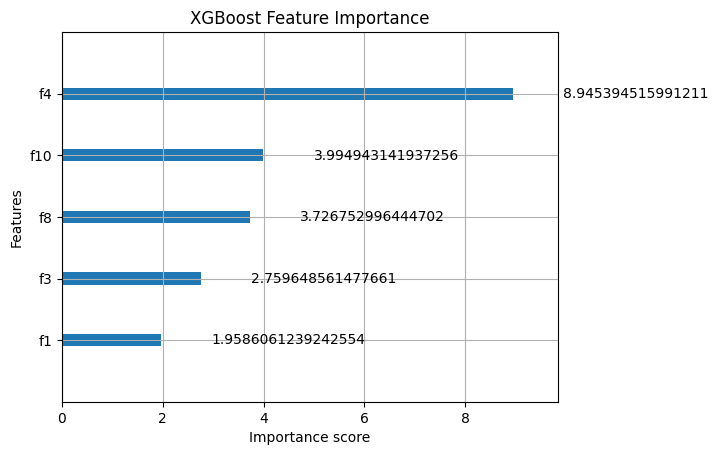

In [104]:
plot_importance(models["XGBoost"], importance_type="gain", max_num_features=5)
plt.title("XGBoost Feature Importance")
plt.show()

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

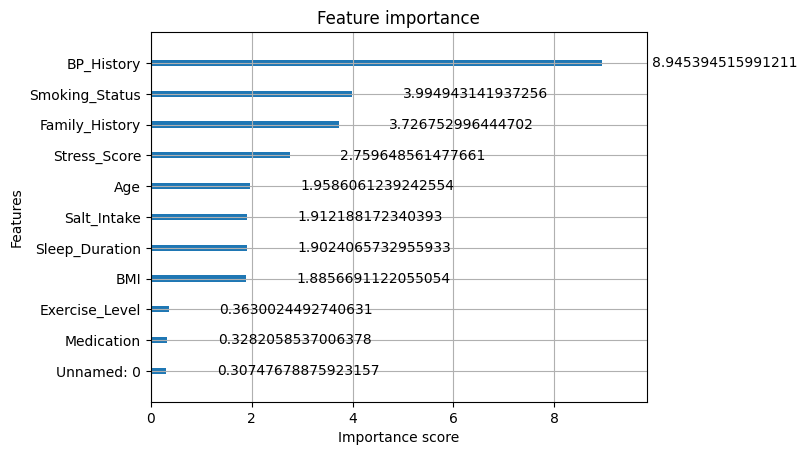

In [110]:
feature_names = X.columns.tolist()

mapper = {f'f{i}': name for i, name in enumerate(feature_names)}

mapper_impotance = {mapper[k]: v for k, v in models["XGBoost"].get_booster().get_score(importance_type="gain").items()}

import xgboost as xgb
xgb.plot_importance(mapper_impotance, importance_type="gain")
#shap_values = shap.TreeExplainer(models["XGBoost"]).shap_values

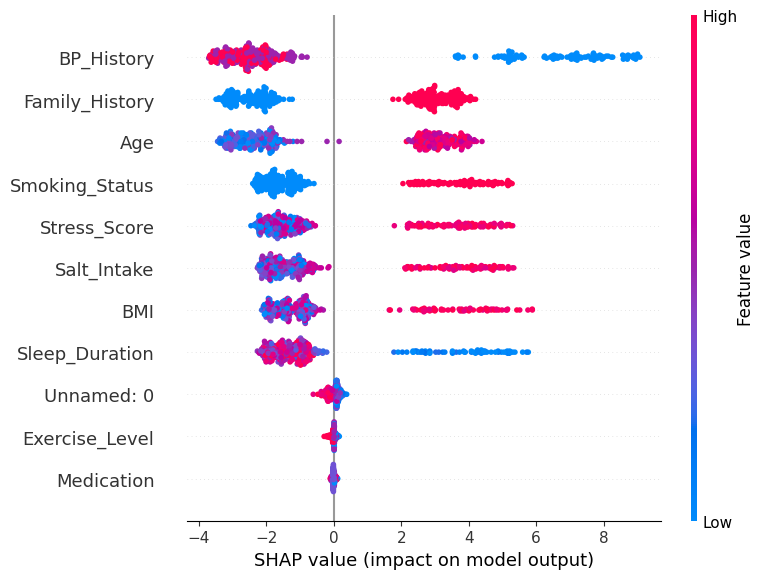

In [111]:
X_test_df  = pd.DataFrame(X_test_scales, columns=X.columns)

explainer = shap.TreeExplainer(models["XGBoost"])
shap_values = explainer.shap_values(X_test_df)

shap.summary_plot(shap_values, X_test_df)

# 5. Expected Findings (Typical Insights)
You may discover:
- High BMI + high stress = strongest predictors. (Partial Match)
- Sleep deprivation significantly increases risk. (Confirmed)
- Lifestyle factors rival gentic factors. (Smoking, Stress, and Salt) - (Confirmed)
- Some "healthy-looking" individuals still fall into risk clusters. (confirmed)